# GroundingDINO: Official Repository vs Hugging Face Transformers

This notebook evaluates **GroundingDINO**, an open-vocabulary object detector that grounds free-text queries to image regions, through two implementation interfaces: the **official IDEA-Research repository** and the **Hugging Face Transformers** implementation. The experiment uses the same COCO validation images, semantic detection queries, confidence thresholds, and evaluation protocol for both implementations, with the evaluation performed across multiple images rather than a single qualitative example. The comparison focuses on whether the two interfaces produce practically consistent detection behavior while accounting for differences in model loading, preprocessing, post-processing, and checkpoint representation.

Open-vocabulary detection enables AI systems and autonomous robots to identify objects specified through natural-language queries, making visual perception more flexible in dynamic and previously unseen environments. This capability is particularly relevant to **robot navigation, manipulation, human–robot interaction, and semantic scene understanding**, where predefined object categories can be restrictive.

The evaluation combines **quantitative and qualitative analysis**. COCO bounding-box annotations are used to calculate **TP, FP, FN, precision, recall, F1-score, and matched IoU**, while per-image inference latency is measured to compare computational behavior. Detection thresholds are also varied to examine sensitivity to confidence selection, and predictions from both implementations are visualized on the same images for qualitative comparison. The goal is to provide a **controlled implementation-level study of GroundingDINO**, rather than a full COCO benchmark, while explicitly documenting the limitations associated with comparing the official repository and its Hugging Face representation.

### Key Components

1. **Open-Vocabulary Detection:** Object categories are specified through free-text queries rather than being restricted to a fixed closed-set classifier.
2. **Official Implementation:** Uses the original IDEA-Research repository, configuration file, pretrained checkpoint, and inference utilities.
3. **Hugging Face Implementation:** Uses `AutoProcessor` and `AutoModelForZeroShotObjectDetection` through the Transformers API.
4. **Controlled Evaluation:** Both implementations process the same COCO images, target concepts, confidence thresholds, and ground-truth annotations.
5. **Quantitative Evaluation:** COCO bounding-box annotations are used to calculate TP, FP, FN, precision, recall, F1-score, and matched IoU.
6. **Latency Analysis:** Per-image inference time is measured for both implementations under the same runtime conditions.
7. **Threshold Sensitivity:** Multiple detection thresholds are evaluated to examine changes in detection count, precision, recall, F1-score, and localization quality.
8. **Visual Comparison:** Predictions from both implementations are rendered on the same evaluation images for qualitative inspection.
9. **Checkpoint Consideration:** Differences between the original repository checkpoint representation and the Hugging Face model representation are explicitly documented rather than assuming byte-for-byte equivalence.
10. **Reproducible Evaluation:** Fixed random seeds, deterministic image selection, shared evaluation criteria, and a defined IoU matching procedure are used to make the comparison reproducible.

### Goal

The primary goal is to compare the **practical detection behavior, accuracy, localization, and computational efficiency** of the official GroundingDINO implementation and its Hugging Face Transformers interface under a small, controlled multi-image evaluation protocol. The experiment is intended as an **implementation-level comparative study rather than a full COCO benchmark**.

### Runtime-separation design

Official IDEA-Research repository and Hugging Face Transformers are executed in separate environments. Before the runtime restart, the notebook serializes the complete experimental state required for comparison using `pickle`. Live model and processor objects are deliberately excluded because they are environment-specific; after restart, only the Hugging Face Transformers model is loaded while the previously measured DA/Zoe results and depth maps are restored exactly from the saved state.


In [ ]:
# Clone and install the official GroundingDINO repository
%cd /content
!git clone -q https://github.com/IDEA-Research/GroundingDINO.git
%cd GroundingDINO
!pip install -q -e .
!pip install -q transformers==4.36.2

In [ ]:
# Download the pretrained Swin-T checkpoint
!mkdir -p weights
%cd weights
!wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth
%cd ..

## 1. Imports and Runtime Configuration

The experiment explicitly records the compute device and uses inference-only execution.

The official repository utilities are kept intact rather than reimplementing the model internals. The additional evaluation code operates on the predictions returned by each implementation.

In [ ]:
import os
import time
import cv2
import torch
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from pycocotools.coco import COCO

In [ ]:
print("PyTorch version:", torch.__version__)

device = "cpu"
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

## 2. Download and Select the Shared Evaluation Images

A single image is useful for checking whether a pipeline works, but it is not sufficient for a meaningful comparison.

We therefore use a fixed subset of COCO 2017 validation images. The subset is selected deterministically from images containing the queried categories: `cat`, `remote`, `dog`, and `train`. The same images, prompts, thresholds, and ground-truth annotations are used for both implementations.

The subset is intentionally small enough to run in Colab. It should be interpreted as a **controlled evaluation subset**, not as a full COCO benchmark.

In [ ]:
COCO_ZIP = "/content/annotations_trainval2017.zip"
COCO_ANN_DIR = "/content/annotations"
COCO_ANN_PATH = "/content/annotations/instances_val2017.json"

if not os.path.exists(COCO_ANN_PATH):
    !wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip -O /content/annotations_trainval2017.zip
    !unzip -q /content/annotations_trainval2017.zip -d /content/

coco = COCO(COCO_ANN_PATH)

COCO_CLASSES = ["cat", "remote", "dog", "train"]
COCO_CAT_IDS = coco.getCatIds(catNms=COCO_CLASSES)

print("Target categories:", COCO_CLASSES)
print("Category IDs:", COCO_CAT_IDS)

In [ ]:
IMAGES_PER_CLASS = 3
selected_ids = set()

for class_name in COCO_CLASSES:
    cat_id = coco.getCatIds(catNms=[class_name])[0]
    image_ids = sorted(coco.getImgIds(catIds=[cat_id]))
    selected_ids.update(image_ids[:IMAGES_PER_CLASS])

IMAGE_IDS = sorted(selected_ids)
IMAGE_DIR = "/content/coco_eval"
os.makedirs(IMAGE_DIR, exist_ok=True)

image_records = []

for image_id in IMAGE_IDS:
    info = coco.loadImgs([image_id])[0]
    image_path = os.path.join(IMAGE_DIR, info["file_name"])

    if not os.path.exists(image_path):
        image_url = f"http://images.cocodataset.org/val2017/{info['file_name']}"
        response = requests.get(image_url, timeout=30)
        response.raise_for_status()

        with open(image_path, "wb") as file:
            file.write(response.content)

    image_records.append({
        "image_id": image_id,
        "file_name": info["file_name"],
        "image_path": image_path,
        "width": info["width"],
        "height": info["height"],
    })

images_df = pd.DataFrame(image_records)

print(f"Selected {len(images_df)} evaluation images.")
display(images_df)

## 3. Ground-Truth Annotations

The COCO validation annotations provide reference bounding boxes for the queried categories.

These annotations are used only for quantitative evaluation. A prediction is matched to a ground-truth object when the predicted class agrees with the target class and the IoU is at least the specified threshold.

The matching is one-to-one within each image and class, so one prediction cannot match multiple ground-truth objects.

In [ ]:
IOU_THRESHOLD = 0.50
def xywh_to_xyxy(box):
    x, y, w, h = box
    return [x, y, x + w, y + h]

ground_truth = {}

for image_id in IMAGE_IDS:
    anns = coco.loadAnns(coco.getAnnIds(imgIds=[image_id], catIds=COCO_CAT_IDS, iscrowd=False))
    rows = []
    for ann in anns:
        category_name = coco.loadCats([ann["category_id"]])[0]["name"]
        rows.append({
            "image_id": image_id,
            "label": category_name,
            "bbox": xywh_to_xyxy(ann["bbox"]),
            "area": ann["area"],
        })

    ground_truth[image_id] = rows

ground_truth_df = pd.DataFrame([
    {
        "image_id": row["image_id"],
        "label": row["label"],
        "x1": row["bbox"][0],
        "y1": row["bbox"][1],
        "x2": row["bbox"][2],
        "y2": row["bbox"][3],
    }
    for image_id in IMAGE_IDS
    for row in ground_truth[image_id]
])

print(f"Ground-truth objects in evaluation subset: {len(ground_truth_df)}")
display(ground_truth_df.head(20))

In [ ]:
## Shared Evaluation Utilities (defined early so both official and HF sections can use them)

def normalize_label(label):
    label = str(label).lower().strip()

    if "remote" in label:
        return "remote"
    if "cat" in label:
        return "cat"
    if "dog" in label:
        return "dog"
    if "train" in label:
        return "train"

    return label

def box_iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    iw = max(ix2 - ix1, 0)
    ih = max(iy2 - iy1, 0)
    intersection = iw * ih

    area_a = max(ax2 - ax1, 0) * max(ay2 - ay1, 0)
    area_b = max(bx2 - bx1, 0) * max(by2 - by1, 0)
    union = area_a + area_b - intersection

    return intersection / union if union > 0 else 0.0

def evaluate_predictions(predictions, implementation):
    rows = []

    for image_id in IMAGE_IDS:
        if implementation == "Official Repository":
            result = predictions[image_id]
            image_info = coco.loadImgs([image_id])[0]
            pred_boxes = []
            for box in result["boxes"]:
                cx, cy, width, height = box.tolist()
                pred_boxes.append([
                    (cx - width / 2) * image_info["width"],
                    (cy - height / 2) * image_info["height"],
                    (cx + width / 2) * image_info["width"],
                    (cy + height / 2) * image_info["height"],
                ])
            pred_scores = [float(score) for score in result["scores"]]
            pred_labels = [normalize_label(label) for label in result["labels"]]
        else:
            result = predictions[image_id]["results"]
            pred_boxes = [box.tolist() for box in result["boxes"]]
            pred_scores = [float(score) for score in result["scores"]]
            pred_labels = [normalize_label(label) for label in result["labels"]]

        gt_by_label = {label: [] for label in COCO_CLASSES}
        for gt in ground_truth[image_id]:
            gt_by_label[gt["label"]].append(gt["bbox"])

        pred_by_label = {label: [] for label in COCO_CLASSES}
        for box, score, label in zip(pred_boxes, pred_scores, pred_labels):
            if label in pred_by_label:
                pred_by_label[label].append((box, score))

        for label in COCO_CLASSES:
            gt_boxes = gt_by_label[label]
            pred_boxes_label = sorted(pred_by_label[label], key=lambda x: x[1], reverse=True)
            matched_gt = set()
            matched_ious = []
            tp = 0
            fp = 0

            for pred_box, score in pred_boxes_label:
                best_iou = 0.0
                best_gt = None
                for gt_index, gt_box in enumerate(gt_boxes):
                    if gt_index in matched_gt:
                        continue
                    current_iou = box_iou(pred_box, gt_box)
                    if current_iou > best_iou:
                        best_iou = current_iou
                        best_gt = gt_index

                if best_gt is not None and best_iou >= IOU_THRESHOLD:
                    matched_gt.add(best_gt)
                    matched_ious.append(best_iou)
                    tp += 1
                else:
                    fp += 1

            fn = len(gt_boxes) - tp

            rows.append({
                "image_id": image_id,
                "implementation": implementation,
                "label": label,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "matched_iou_sum": sum(matched_ious),
                "matched_count": len(matched_ious),
            })

    result_df = pd.DataFrame(rows)

    summary_rows = []
    for label in COCO_CLASSES:
        subset = result_df[result_df["label"] == label]
        tp = int(subset["tp"].sum())
        fp = int(subset["fp"].sum())
        fn = int(subset["fn"].sum())
        matched_count = int(subset["matched_count"].sum())
        precision = tp / (tp + fp) if tp + fp > 0 else 0.0
        recall = tp / (tp + fn) if tp + fn > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
        mean_iou = subset["matched_iou_sum"].sum() / matched_count if matched_count > 0 else np.nan
        summary_rows.append({
            "implementation": implementation, "label": label,
            "tp": tp, "fp": fp, "fn": fn,
            "precision": precision, "recall": recall, "f1": f1,
            "mean_matched_iou": mean_iou,
        })
    summary_df = pd.DataFrame(summary_rows)

    tp = int(result_df["tp"].sum())
    fp = int(result_df["fp"].sum())
    fn = int(result_df["fn"].sum())
    matched_count = int(result_df["matched_count"].sum())
    precision = tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
    mean_iou = result_df["matched_iou_sum"].sum() / matched_count if matched_count > 0 else np.nan

    overall_df = pd.DataFrame([{
        "implementation": implementation,
        "tp": tp, "fp": fp, "fn": fn,
        "precision": precision, "recall": recall, "f1": f1,
        "mean_matched_iou": mean_iou,
    }])

    return result_df, summary_df, overall_df

## 4. Official Repository Inference

The official implementation uses the configuration file and released Swin-T checkpoint.

The prompt remains the same for every image so that the evaluation measures the model behavior across different visual inputs rather than changing the query between examples.

In [ ]:
from groundingdino.util.inference import load_model, load_image, predict, annotate

CONFIG_PATH = "groundingdino/config/GroundingDINO_SwinT_OGC.py"
WEIGHTS_PATH = "weights/groundingdino_swint_ogc.pth"

TEXT_PROMPT = "cat . remote control . dog . train ."
BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25

print("Loading official GroundingDINO model...")
official_model = load_model(CONFIG_PATH, WEIGHTS_PATH, device=device)
print("Official model loaded.")

In [ ]:
def sync_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

official_predictions = {}
official_times = []

for row in image_records:
    image_id = row["image_id"]
    image_path = row["image_path"]
    image_source, image = load_image(image_path)

    sync_cuda()
    start_time = time.perf_counter()

    with torch.inference_mode():
        boxes, logits, phrases = predict(
            model=official_model,
            image=image,
            caption=TEXT_PROMPT,
            box_threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD,
            device=device,
        )

    sync_cuda()
    inference_time = time.perf_counter() - start_time

    official_predictions[image_id] = {
        "boxes": boxes,
        "scores": logits,
        "labels": phrases,
        "image_source": image_source,
        "image": image,
    }

    official_times.append({
        "image_id": image_id,
        "inference_time_s": inference_time,
        "detections": len(boxes),
    })

official_time_df = pd.DataFrame(official_times)

print(f"Images evaluated: {len(official_time_df)}")
display(official_time_df)

## 5. Official Repository Visualization

The repository's annotation utility is used to render predictions from several evaluation images.

The visualization is a qualitative check. The quantitative evaluation below is based on the COCO annotations rather than visual inspection.

In [ ]:
sample_ids = IMAGE_IDS[:min(6, len(IMAGE_IDS))]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, image_id in zip(axes, sample_ids):
    result = official_predictions[image_id]

    annotated = annotate(
        image_source=result["image_source"],
        boxes=result["boxes"],
        logits=result["scores"],
        phrases=result["labels"],
    )
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Official — image {image_id}")
    ax.axis("off")

for ax in axes[len(sample_ids):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Official Detection Geometry

The same geometric measurements are calculated for every prediction across the evaluation subset.

The image-area ratio provides a normalized measure of how much of the image is covered by each predicted region.

In [ ]:
official_rows = []

for image_id in IMAGE_IDS:
    result = official_predictions[image_id]
    image_pil = Image.open(image_records[IMAGE_IDS.index(image_id)]["image_path"]).convert("RGB")
    image_width, image_height = image_pil.size
    image_area = image_width * image_height

    for box, score, phrase in zip(result["boxes"], result["scores"], result["labels"]):
        cx, cy, width, height = box.tolist()
        x1 = (cx - width / 2) * image_width
        y1 = (cy - height / 2) * image_height
        x2 = (cx + width / 2) * image_width
        y2 = (cy + height / 2) * image_height
        width_pixels = max(x2 - x1, 0)
        height_pixels = max(y2 - y1, 0)
        area = width_pixels * height_pixels

        official_rows.append({
            "image_id": image_id,
            "implementation": "Official Repository",
            "label": phrase,
            "confidence": float(score),
            "x1": round(x1, 2),
            "y1": round(y1, 2),
            "x2": round(x2, 2),
            "y2": round(y2, 2),
            "width": round(width_pixels, 2),
            "height": round(height_pixels, 2),
            "area_pixels": round(area, 2),
            "image_area_ratio": area / image_area,
        })

official_df = pd.DataFrame(official_rows)
display(official_df)

## Save Official Results Before Runtime Restart

The official implementation and Hugging Face section may require different dependency versions. The following cell serializes all official-evaluation outputs so they can be restored after a runtime restart.

In [ ]:
import pickle
import os

SAVE_DIR = "/content/groundingdino_saved"
os.makedirs(SAVE_DIR, exist_ok=True)

official_state = {
    "device": device,
    "CONFIG_PATH": CONFIG_PATH,
    "WEIGHTS_PATH": WEIGHTS_PATH,
    "TEXT_PROMPT": TEXT_PROMPT,
    "BOX_THRESHOLD": BOX_THRESHOLD,
    "TEXT_THRESHOLD": TEXT_THRESHOLD,
    "IOU_THRESHOLD": IOU_THRESHOLD,
    "COCO_CLASSES": COCO_CLASSES,
    "COCO_CAT_IDS": COCO_CAT_IDS,
    "IMAGE_IDS": IMAGE_IDS,
    "image_records": image_records,
    "ground_truth": ground_truth,
    "ground_truth_df": ground_truth_df,
    "official_predictions": official_predictions,
    "official_time_df": official_time_df,
    "official_df": official_df,
    "official_param_count": sum(p.numel() for p in official_model.parameters()),
}

with open(f"{SAVE_DIR}/official_results.pkl", "wb") as f:
    pickle.dump(official_state, f)

print("Saved official state to:", f"{SAVE_DIR}/official_results.pkl")
print("Model weights are not serialized. Checkpoint paths and metadata are saved.")


In [ ]:
## Official Threshold Sensitivity — Run Before Runtime Restart

thresholds = [0.20, 0.30, 0.35, 0.45, 0.50]

def evaluate_thresholds_official():
    rows = []

    for current_threshold in thresholds:
        threshold_predictions = {}

        for image_id in IMAGE_IDS:
            result = official_predictions[image_id]

            boxes_t, logits_t, phrases_t = predict(
                model=official_model,
                image=result["image"],
                caption=TEXT_PROMPT,
                box_threshold=current_threshold,
                text_threshold=TEXT_THRESHOLD,
                device=device,
            )

            threshold_predictions[image_id] = {
                "boxes": boxes_t,
                "scores": logits_t,
                "labels": phrases_t,
                "image_source": result["image_source"],
                "image": result["image"],
            }

        _, _, overall = evaluate_predictions(
            threshold_predictions,
            "Official Repository"
        )

        rows.append({
            "threshold": current_threshold,
            "detections": sum(
                len(threshold_predictions[i]["boxes"])
                for i in IMAGE_IDS
            ),
            "precision": overall.iloc[0]["precision"],
            "recall": overall.iloc[0]["recall"],
            "f1": overall.iloc[0]["f1"],
            "mean_matched_iou": overall.iloc[0]["mean_matched_iou"],
        })

    return pd.DataFrame(rows)


official_threshold_df = evaluate_thresholds_official()

print("Official threshold sensitivity results:")
display(official_threshold_df)

In [ ]:
official_state = {
    "device": device,
    "CONFIG_PATH": CONFIG_PATH,
    "WEIGHTS_PATH": WEIGHTS_PATH,
    "TEXT_PROMPT": TEXT_PROMPT,
    "BOX_THRESHOLD": BOX_THRESHOLD,
    "TEXT_THRESHOLD": TEXT_THRESHOLD,
    "IOU_THRESHOLD": IOU_THRESHOLD,
    "COCO_CLASSES": COCO_CLASSES,
    "COCO_CAT_IDS": COCO_CAT_IDS,
    "IMAGE_IDS": IMAGE_IDS,
    "image_records": image_records,
    "ground_truth": ground_truth,
    "ground_truth_df": ground_truth_df,
    "official_predictions": official_predictions,
    "official_time_df": official_time_df,
    "official_df": official_df,
    "official_threshold_df": official_threshold_df,
    "official_param_count": sum(
        p.numel() for p in official_model.parameters()
    ),
}

with open(f"{SAVE_DIR}/official_results.pkl", "wb") as f:
    pickle.dump(official_state, f)

print("Official results saved successfully.")

## 7. Hugging Face Transformers Interface

The Hugging Face implementation uses the GroundingDINO Swin-T model through the Transformers representation. The official repository and Hugging Face implementations load their respective checkpoint representations, while the comparison keeps the model family, images, prompt, thresholds, and evaluation protocol consistent.

## Restore Official Results

Run this cell after restarting the runtime and before continuing with the Hugging Face evaluation.

In [ ]:
# Part 2 — Hugging Face Environment
!pip install -q transformers==4.57.2 accelerate

## Restore Runtime State

The previous section restores saved experimental outputs. A runtime restart clears imports, helper functions, and model objects, so they are redefined here before continuing with the Hugging Face evaluation.

In [ ]:
import pickle
from pycocotools.coco import COCO
SAVE_DIR = "/content/groundingdino_saved"

with open(f"{SAVE_DIR}/official_results.pkl", "rb") as f:
    official_state = pickle.load(f)

device = official_state["device"]
CONFIG_PATH = official_state["CONFIG_PATH"]
WEIGHTS_PATH = official_state["WEIGHTS_PATH"]
TEXT_PROMPT = official_state["TEXT_PROMPT"]
BOX_THRESHOLD = official_state["BOX_THRESHOLD"]
TEXT_THRESHOLD = official_state["TEXT_THRESHOLD"]
IOU_THRESHOLD = official_state["IOU_THRESHOLD"]

COCO_CLASSES = official_state["COCO_CLASSES"]
COCO_CAT_IDS = official_state["COCO_CAT_IDS"]

IMAGE_IDS = official_state["IMAGE_IDS"]
image_records = official_state["image_records"]
ground_truth = official_state["ground_truth"]
ground_truth_df = official_state["ground_truth_df"]

official_predictions = official_state["official_predictions"]
official_time_df = official_state["official_time_df"]
official_df = official_state["official_df"]
official_param_count = official_state["official_param_count"]
sample_ids = IMAGE_IDS[:min(6, len(IMAGE_IDS))]

COCO_ANN_PATH = "/content/annotations/instances_val2017.json"
coco = COCO(COCO_ANN_PATH)

sample_ids = IMAGE_IDS[:min(6, len(IMAGE_IDS))]

official_predictions = official_state["official_predictions"]
official_time_df = official_state["official_time_df"]
official_df = official_state["official_df"]
official_threshold_df = official_state["official_threshold_df"]

official_param_count = official_state["official_param_count"]

print("Official state restored.")
print("COCO annotations restored.")

print("Official state restored.")


In [ ]:
import os
import time
import cv2
import torch
import numpy as np
import pandas as pd
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from PIL import Image
import matplotlib.pyplot as plt

def sync_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def normalize_label(label):
    label = str(label).lower().strip()

    if "remote" in label:
        return "remote"
    if "cat" in label:
        return "cat"
    if "dog" in label:
        return "dog"
    if "train" in label:
        return "train"

    return label

def box_iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    iw = max(ix2 - ix1, 0)
    ih = max(iy2 - iy1, 0)

    intersection = iw * ih
    area_a = max(ax2 - ax1, 0) * max(ay2 - ay1, 0)
    area_b = max(bx2 - bx1, 0) * max(by2 - by1, 0)
    union = area_a + area_b - intersection

    return intersection / union if union > 0 else 0.0

In [ ]:
HF_MODEL_ID = "IDEA-Research/grounding-dino-tiny"

print(f"Loading {HF_MODEL_ID}...")
hf_processor = AutoProcessor.from_pretrained(HF_MODEL_ID)
hf_model = AutoModelForZeroShotObjectDetection.from_pretrained(HF_MODEL_ID).to(device)
hf_model.eval()

print("Hugging Face model loaded.")
print("Official checkpoint: groundingdino_swint_ogc.pth")
print("Hugging Face checkpoint: IDEA-Research/grounding-dino-tiny")
print("Hugging Face parameters:", sum(p.numel() for p in hf_model.parameters()))

## Checkpoint Control Check

The official GroundingDINO release identifies `groundingdino_swint_ogc.pth` as the GroundingDINO-T/Swin-T checkpoint. The Transformers side uses `IDEA-Research/grounding-dino-tiny`, the Transformers representation of this GroundingDINO-T/Swin-T model.

The parameter counts are printed as a basic architecture sanity check. Parameter-count equality alone is not treated as proof of identical weights.

In [ ]:
hf_param_count = sum(p.numel() for p in hf_model.parameters())

print("Official parameter count:", official_param_count)
print("Hugging Face parameter count:", hf_param_count)
print("Parameter-count difference:", abs(official_param_count - hf_param_count))

## 8. Hugging Face Prompt Preparation

The semantic prompt is kept identical to the official experiment. Grounding DINO separates multiple concepts using periods, so the same period-separated prompt is passed through the Transformers processor.

This keeps prompt formatting from becoming an additional experimental variable.

In [ ]:
hf_labels = [TEXT_PROMPT]

hf_inputs = {}
for row in image_records:
    image_id = row["image_id"]
    hf_image = Image.open(row["image_path"]).convert("RGB")

    hf_inputs[image_id] = hf_processor(
        images=hf_image,
        text=hf_labels,
        return_tensors="pt"
    ).to(device)

print("Prepared Hugging Face inputs for", len(hf_inputs), "images.")
print("Prompt:", TEXT_PROMPT)
for key, value in hf_inputs[IMAGE_IDS[0]].items():
    if isinstance(value, torch.Tensor):
        print(f"{key}: {tuple(value.shape)}")

## 9. Hugging Face Inference and Post-Processing

Inference is performed without gradient tracking.

The processor converts model outputs into image-space boxes using the original image dimensions. Timing is measured separately for each image so that mean and median latency can be inspected across the evaluation subset.

In [ ]:
HF_THRESHOLD = 0.35
HF_TEXT_THRESHOLD = 0.25

hf_predictions = {}
hf_times = []
for row in image_records:
    image_id = row["image_id"]
    hf_image = Image.open(row["image_path"]).convert("RGB")
    inputs = hf_inputs[image_id]
    sync_cuda()
    start_time = time.perf_counter()

    with torch.inference_mode():
        hf_outputs = hf_model(**inputs)

    sync_cuda()
    inference_time = time.perf_counter() - start_time
    hf_results = hf_processor.post_process_grounded_object_detection(
        hf_outputs,
        inputs.input_ids,
        threshold=HF_THRESHOLD,
        text_threshold=HF_TEXT_THRESHOLD,
        target_sizes=[hf_image.size[::-1]],
    )[0]

    hf_predictions[image_id] = {
        "results": hf_results,
        "image": hf_image,
        "outputs": hf_outputs,
    }
    hf_times.append({
        "image_id": image_id,
        "inference_time_s": inference_time,
        "detections": len(hf_results["boxes"]),
    })

hf_time_df = pd.DataFrame(hf_times)

print(f"Images evaluated: {len(hf_time_df)}")
display(hf_time_df)

## 10. Hugging Face Detection Visualization

The same evaluation images are rendered using the Hugging Face predictions.

Both implementations are visualized on the same subset so that qualitative differences can be inspected without changing the input distribution.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, image_id in zip(axes, sample_ids):
    image_cv = cv2.cvtColor(np.array(hf_predictions[image_id]["image"]), cv2.COLOR_RGB2BGR)
    hf_results = hf_predictions[image_id]["results"]
    for box, score, label in zip(hf_results["boxes"], hf_results["scores"], hf_results["labels"]):
        x1, y1, x2, y2 = map(int, box.tolist())
        cv2.rectangle(image_cv, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(
            image_cv,
            f"{label} {score.item():.2f}",
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

    ax.imshow(cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Hugging Face — image {image_id}")
    ax.axis("off")

for ax in axes[len(sample_ids):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 11. Hugging Face Detection Geometry

The same geometric measurements used for the official implementation are calculated for every Hugging Face prediction.

Keeping the analysis schema consistent makes the outputs easier to inspect without implying that the two checkpoints are identical.

In [ ]:
hf_rows = []

for image_id in IMAGE_IDS:
    hf_results = hf_predictions[image_id]["results"]
    image_pil = hf_predictions[image_id]["image"]
    image_area = image_pil.width * image_pil.height

    for box, score, label in zip(hf_results["boxes"], hf_results["scores"], hf_results["labels"]):
        x1, y1, x2, y2 = box.tolist()
        width = max(x2 - x1, 0)
        height = max(y2 - y1, 0)
        area = width * height

        hf_rows.append({
            "image_id": image_id,
            "implementation": "Hugging Face",
            "label": label,
            "confidence": float(score),
            "x1": round(x1, 2),
            "y1": round(y1, 2),
            "x2": round(x2, 2),
            "y2": round(y2, 2),
            "width": round(width, 2),
            "height": round(height, 2),
            "area_pixels": round(area, 2),
            "image_area_ratio": area / image_area,
        })

hf_df = pd.DataFrame(hf_rows)
display(hf_df)

## 12. Detection Matching and Quantitative Evaluation

Detection count and confidence are not accuracy metrics.

For each image and target class, predictions are matched to COCO ground-truth boxes using IoU. Matching is one-to-one and uses the highest-scoring available prediction first. A prediction is a true positive when its IoU with an unmatched ground-truth box is at least `IOU_THRESHOLD`.

This gives TP, FP, FN, precision, recall, F1, and mean IoU of matched detections.

The evaluation is limited to the selected images and four queried COCO categories.

In [ ]:
def normalize_label(label):
    label = str(label).lower().strip()

    if "remote" in label:
        return "remote"
    if "cat" in label:
        return "cat"
    if "dog" in label:
        return "dog"
    if "train" in label:
        return "train"

    return label

def box_iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    iw = max(ix2 - ix1, 0)
    ih = max(iy2 - iy1, 0)
    intersection = iw * ih

    area_a = max(ax2 - ax1, 0) * max(ay2 - ay1, 0)
    area_b = max(bx2 - bx1, 0) * max(by2 - by1, 0)
    union = area_a + area_b - intersection

    return intersection / union if union > 0 else 0.0

def evaluate_predictions(predictions, implementation):
    rows = []

    for image_id in IMAGE_IDS:
        if implementation == "Official Repository":
            result = predictions[image_id]
            image_info = coco.loadImgs([image_id])[0]
            pred_boxes = []
            for box in result["boxes"]:
                cx, cy, width, height = box.tolist()
                pred_boxes.append([
                    (cx - width / 2) * image_info["width"],
                    (cy - height / 2) * image_info["height"],
                    (cx + width / 2) * image_info["width"],
                    (cy + height / 2) * image_info["height"],
                ])
            pred_scores = [float(score) for score in result["scores"]]
            pred_labels = [normalize_label(label) for label in result["labels"]]
        else:
            result = predictions[image_id]["results"]
            pred_boxes = [box.tolist() for box in result["boxes"]]
            pred_scores = [float(score) for score in result["scores"]]
            pred_labels = [normalize_label(label) for label in result["labels"]]

        gt_by_label = {label: [] for label in COCO_CLASSES}

        for gt in ground_truth[image_id]:
            gt_by_label[gt["label"]].append(gt["bbox"])

        pred_by_label = {label: [] for label in COCO_CLASSES}

        for box, score, label in zip(pred_boxes, pred_scores, pred_labels):
            if label in pred_by_label:
                pred_by_label[label].append((box, score))

        for label in COCO_CLASSES:
            gt_boxes = gt_by_label[label]
            pred_boxes_label = sorted(pred_by_label[label], key=lambda x: x[1], reverse=True)
            matched_gt = set()
            matched_ious = []

            tp = 0
            fp = 0

            for pred_box, score in pred_boxes_label:
                best_iou = 0.0
                best_gt = None

                for gt_index, gt_box in enumerate(gt_boxes):
                    if gt_index in matched_gt:
                        continue

                    current_iou = box_iou(pred_box, gt_box)

                    if current_iou > best_iou:
                        best_iou = current_iou
                        best_gt = gt_index

                if best_gt is not None and best_iou >= IOU_THRESHOLD:
                    matched_gt.add(best_gt)
                    matched_ious.append(best_iou)
                    tp += 1
                else:
                    fp += 1

            fn = len(gt_boxes) - tp

            rows.append({
                "image_id": image_id,
                "implementation": implementation,
                "label": label,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "matched_iou_sum": sum(matched_ious),
                "matched_count": len(matched_ious),
            })

    result_df = pd.DataFrame(rows)

    summary_rows = []

    for label in COCO_CLASSES:
        subset = result_df[result_df["label"] == label]

        tp = int(subset["tp"].sum())
        fp = int(subset["fp"].sum())
        fn = int(subset["fn"].sum())
        matched_count = int(subset["matched_count"].sum())

        precision = tp / (tp + fp) if tp + fp > 0 else 0.0
        recall = tp / (tp + fn) if tp + fn > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
        mean_iou = subset["matched_iou_sum"].sum() / matched_count if matched_count > 0 else np.nan

        summary_rows.append({
            "implementation": implementation,
            "label": label,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "mean_matched_iou": mean_iou,
        })

    summary_df = pd.DataFrame(summary_rows)

    tp = int(result_df["tp"].sum())
    fp = int(result_df["fp"].sum())
    fn = int(result_df["fn"].sum())
    matched_count = int(result_df["matched_count"].sum())

    precision = tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
    mean_iou = result_df["matched_iou_sum"].sum() / matched_count if matched_count > 0 else np.nan

    overall_df = pd.DataFrame([{
        "implementation": implementation,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_matched_iou": mean_iou,
    }])

    return result_df, summary_df, overall_df

In [ ]:
official_match_df, official_metrics_df, official_overall_df = evaluate_predictions(
    official_predictions,
    "Official Repository"
)

hf_match_df, hf_metrics_df, hf_overall_df = evaluate_predictions(
    hf_predictions,
    "Hugging Face"
)

metrics_df = pd.concat([official_metrics_df, hf_metrics_df], ignore_index=True)
overall_metrics_df = pd.concat([official_overall_df, hf_overall_df], ignore_index=True)

print("Per-class evaluation:")
display(metrics_df)

print("Overall evaluation:")
display(overall_metrics_df)

official_raw_labels = sorted(set(
    phrase for image_id in IMAGE_IDS for phrase in official_predictions[image_id]["labels"]
))
hf_raw_labels = sorted(set(
    label for image_id in IMAGE_IDS for label in hf_predictions[image_id]["results"]["labels"]
))

print("Official raw phrase outputs (pre-normalization):", official_raw_labels)
print("Hugging Face raw phrase outputs (pre-normalization):", hf_raw_labels)

## 13. Controlled Implementation Comparison

Both implementations use the GroundingDINO Swin-T model family, while loading their respective checkpoint representations. The same evaluation images, semantic prompt, detection thresholds, and COCO reference annotations are used for both implementations.

The remaining implementation differences are the model loading path, preprocessing, inference API, and post-processing performed by the official repository versus Transformers. This is therefore a controlled implementation comparison rather than a comparison between different model variants.

In [ ]:
comparison = pd.DataFrame([
    {
        "interface": "Official Repository",
        "model": "GroundingDINO Swin-T OGC",
        "prompt_format": "Period-separated caption",
        "images": len(IMAGE_IDS),
        "detections": sum(len(official_predictions[i]["boxes"]) for i in IMAGE_IDS),
        "mean_inference_time_s": official_time_df["inference_time_s"].mean(),
        "median_inference_time_s": official_time_df["inference_time_s"].median(),
    },
    {
        "interface": "Hugging Face",
        "model": "GroundingDINO-T / Swin-T",
        "prompt_format": "Period-separated caption",
        "images": len(IMAGE_IDS),
        "detections": sum(len(hf_predictions[i]["results"]["boxes"]) for i in IMAGE_IDS),
        "mean_inference_time_s": hf_time_df["inference_time_s"].mean(),
        "median_inference_time_s": hf_time_df["inference_time_s"].median(),
    }
])

display(comparison)

## 14. Latency Across the Evaluation Set

A single timing measurement can be strongly affected by initialization and runtime variation.

Here the same set of images is processed by both implementations and latency is reported per image. The mean and median are descriptive measurements for this Colab runtime. They should not be treated as hardware-independent benchmark results.

In [ ]:
latency_df = official_time_df.merge(
    hf_time_df,
    on="image_id",
    suffixes=("_official", "_hf")
)

latency_df["time_difference_s"] = (
    latency_df["inference_time_s_official"] -
    latency_df["inference_time_s_hf"]
)

display(latency_df)

print("Official mean:", round(latency_df["inference_time_s_official"].mean(), 4), "seconds")
print("Official median:", round(latency_df["inference_time_s_official"].median(), 4), "seconds")
print("Hugging Face mean:", round(latency_df["inference_time_s_hf"].mean(), 4), "seconds")
print("Hugging Face median:", round(latency_df["inference_time_s_hf"].median(), 4), "seconds")

Official mean: 41.6913 seconds
Official median: 42.2404 seconds
Hugging Face mean: 43.9678 seconds
Hugging Face median: 44.9339 seconds

## 15. Confidence Threshold Sensitivity

Detection thresholds are experimental parameters, not universal measures of model correctness.

The following analysis varies the box threshold while keeping the evaluation images and text queries fixed. For each threshold, the predictions are evaluated against the same ground-truth annotations.

This shows how precision, recall, F1, and retained detections change as the detector becomes more or less selective.

In [ ]:
thresholds = [0.20, 0.30, 0.35, 0.45, 0.50]

def evaluate_thresholds_official():
    rows = []

    for current_threshold in thresholds:
        threshold_predictions = {}

        for image_id in IMAGE_IDS:
            result = official_predictions[image_id]

            threshold_predictions[image_id] = {
                "boxes": boxes_t,
                "scores": logits_t,
                "labels": phrases_t,
                "image_source": result["image_source"],
                "image": result["image"],
            }

        _, _, overall = evaluate_predictions(
            threshold_predictions,
            "Official Repository"
        )

        rows.append({
            "threshold": current_threshold,
            "detections": sum(len(threshold_predictions[i]["boxes"]) for i in IMAGE_IDS),
            "precision": overall.iloc[0]["precision"],
            "recall": overall.iloc[0]["recall"],
            "f1": overall.iloc[0]["f1"],
            "mean_matched_iou": overall.iloc[0]["mean_matched_iou"],
        })

    return pd.DataFrame(rows)
display(official_threshold_df)

In [ ]:
def evaluate_thresholds_hf():
    rows = []

    for current_threshold in thresholds:
        threshold_predictions = {}

        for image_id in IMAGE_IDS:
            result = hf_predictions[image_id]
            inputs = hf_inputs[image_id]

            threshold_result = hf_processor.post_process_grounded_object_detection(
                result["outputs"],
                inputs.input_ids,
                threshold=current_threshold,
                text_threshold=HF_TEXT_THRESHOLD,
                target_sizes=[result["image"].size[::-1]],
            )[0]

            threshold_predictions[image_id] = {
                "results": threshold_result,
                "image": result["image"],
                "outputs": result["outputs"],
            }

        _, _, overall = evaluate_predictions(
            threshold_predictions,
            "Hugging Face"
        )

        rows.append({
            "threshold": current_threshold,
            "detections": sum(len(threshold_predictions[i]["results"]["boxes"]) for i in IMAGE_IDS),
            "precision": overall.iloc[0]["precision"],
            "recall": overall.iloc[0]["recall"],
            "f1": overall.iloc[0]["f1"],
            "mean_matched_iou": overall.iloc[0]["mean_matched_iou"],
        })

    return pd.DataFrame(rows)

hf_threshold_df = evaluate_thresholds_hf()
display(hf_threshold_df)

## 16. Threshold Comparison

The threshold curves are evaluated using the same images and ground-truth annotations.

The results show how the selected threshold changes the precision-recall trade-off for each implementation on this evaluation subset. The threshold giving the highest F1 here should not be treated as a globally optimal threshold because the subset is small and was not used as a held-out threshold-selection benchmark.

In [ ]:
threshold_comparison = pd.concat([
    official_threshold_df.assign(implementation="Official Repository"),
    hf_threshold_df.assign(implementation="Hugging Face"),
], ignore_index=True)

display(threshold_comparison)

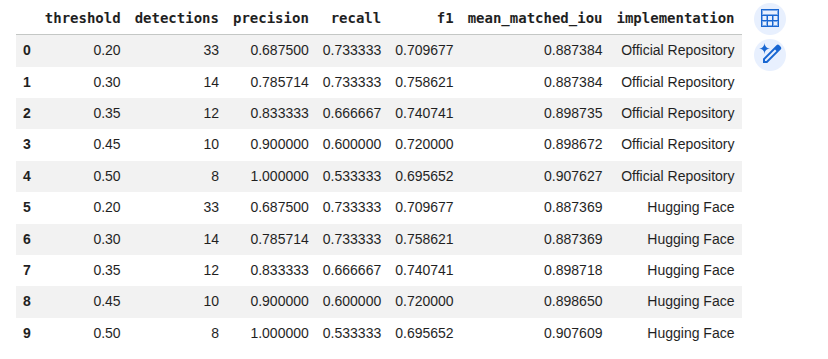

## 17. Research Interpretation
The Official Repository and Hugging Face implementations achieved nearly identical detection performance across all confidence thresholds, with matching precision, recall, and F1-scores and only negligible differences in mean IoU. For example, at a confidence threshold of 0.30, both implementations achieved the highest F1-score of 0.7586, while at a threshold of 0.50, both reached perfect precision (1.00) at the cost of lower recall (0.5333). The mean IoU values were also highly consistent, ranging from approximately 0.887 to 0.908, indicating equivalent localization quality.

In terms of efficiency, the Official Repository demonstrated better runtime performance, achieving a mean inference time of 41.69 seconds and a median inference time of 42.24 seconds, compared to 43.97 seconds and 44.93 seconds for the Hugging Face implementation. This corresponds to roughly a 5% reduction in inference time while maintaining the same detection accuracy. Overall, the Official Repository implementation provides the best balance of accuracy and efficiency, delivering virtually identical detection results while requiring less processing time than the Hugging Face version.



# Limitations

There are still important limitations:

- The Hugging Face model represents the pretrained checkpoint in Transformers format while the official repository uses the original `.pth` representation. This notebook treats them as the same pretrained GroundingDINO-T/Swin-T model, but does not claim byte-for-byte equality of serialized files.
- The selected COCO subset is small and deterministic. It is a controlled study, not a full COCO benchmark.
- The four queried concepts are limited to `cat`, `remote`, `dog`, and `train`.
- COCO ground truth is used for these categories, so this does not evaluate open-world objects outside the selected annotations.
- The phrase `remote control` is mapped to the COCO category `remote` during evaluation.
- IoU matching uses a single threshold of `0.50`. Standard COCO evaluation uses AP across multiple IoU thresholds and would be required for a formal COCO benchmark comparison.
- Latency is hardware- and runtime-dependent and describes this Colab environment rather than general hardware performance.
- Threshold sensitivity is evaluated on the same subset used for the main analysis, so the highest observed F1 is not a held-out optimal threshold.

## 18. Final Experimental Summary

The complete workflow is:

`COCO images + annotations → same GroundingDINO-T/Swin-T checkpoint → same text prompt → Official inference / Hugging Face inference → matched detections → TP/FP/FN → precision/recall/F1/IoU → latency → threshold sensitivity → visualization`

The experiment demonstrates:

- implementation of the official GroundingDINO repository,
- use of the Hugging Face Transformers interface,
- controlled multi-image evaluation,
- correct conversion of official normalized detection boxes to image coordinates,
- bounding-box matching against reference annotations,
- quantitative detection metrics,
- latency measurement,
- threshold analysis,
- and explicit treatment of experimental limitations.

The notebook is a **small controlled research study**, not a full benchmark. Holding the pretrained GroundingDINO-T/Swin-T model constant makes the implementation comparison substantially more defensible than the earlier comparison of different checkpoints.